In [1]:
from fmpy import *
fmu_filename = 'andris_tut.cstr_model.fmu'

Ci, Ti, Tci, Qc = [0.97, 351.5, 351.6, 150]

start_values={'UA':7E5,'k_0':7.2E10,'Ci':Ci,'Ti':Ti,'Tci':Tci,'Qc':Qc}

result = simulate_fmu(fmu_filename,start_values=start_values,stop_time=20,solver='Euler',step_size=0.01,output_interval=0.01)         # simulate the FMU


In [2]:
result

SimulationResult([(0.000e+00, 0.1       , 430.        , 416.        ),
                  (1.000e-02, 0.10007915, 429.96750403, 416.14      ),
                  (2.000e-02, 0.10016329, 429.94216923, 416.13825282),
                  ...,
                  (1.998e+01, 0.10783173, 428.69663381, 415.09134548),
                  (1.999e+01, 0.10783173, 428.69663382, 415.09134549),
                  (2.000e+01, 0.10783173, 428.69663383, 415.0913455 )],
                 dtype=[('time', '<f8'), ('C', '<f8'), ('T', '<f8'), ('Tc', '<f8')])

In [3]:
t = [item[0] for item in result]
C = [item[1] for item in result]

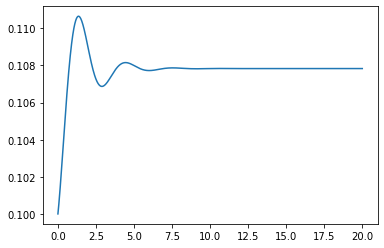

In [4]:
import matplotlib.pyplot as plt
plt.plot(t,C)

In [5]:
from tools import run_sbi, pre_simulator
import numpy as np

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt

inlet_conditions =  [0.87, 351.5, 351.6, 150]
true_params = [7E5, 7.2E10]

# Use simulator to get observation
observation = np.round(pre_simulator(inlet_conditions, true_params),2)
print(observation)

[  0.81 356.85 355.87]


In [6]:
import warnings

def simulator(params):
    
    try:
    
        Ci, Ti, Tci, Qc = [0.97, 351.5, 351.6, 150]
        UA, k_0 = params
        UA =1E5*UA
        k_0=1E10*k_0
        y0 = np.array([0.1,430,416])

        start_values={'UA':UA,'k_0':k_0,'Ci':Ci,'Ti':Ti,'Tci':Tci,'Qc':Qc}

        result = simulate_fmu(fmu_filename,start_values=start_values,stop_time=20,solver='Euler',step_size=0.01,output_interval=0.01)

        output = np.array([result[-1][1], result[-1][2], result[-1][3]])
        output_5 = np.array([result[-5][1], result[-5][2], result[-5][3]])

        # Check tolerance 
        abs_error = abs(output - output_5)
        rel_error = abs_error*100/y0
        error_percentage = 1

        # If simulation is outside of local tolerance, then issue warning and return array of null values
        if any(rel_error>error_percentage):
            warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
            return [np.nan, np.nan, np.nan]

        return output
    
    except:
        return [np.nan, np.nan, np.nan]
        
    

    

In [8]:
from functools import partial
from sbi import utils as utils
from sbi.inference.base import infer
from sbi import analysis

prior = utils.BoxUniform(low=[6,1], 
                         high=[10,10])

posterior = infer(simulator, prior, method='SNPE', num_simulations=100, num_workers=1)

Running 100 simulations.:   0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 143 epochs.

[700000.0, 72000000000.0]

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [1.53251881 0.02063073 0.01864764]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [3.09344409 0.1217192  0.10671569]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [2.66298295 0.0587116  0.05300757]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [2.75658052 0.10516656 0.09064542]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [1.27112702 0.06768885 0.05695316]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [4.03820819 0.13253611 0.11880237]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [2.75649278 0.09376096 0.08098724]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [2.41456784 0.10215384 0.08694242]
/tmp/ipykernel_432242/515007916.py:27: RuntimeWarning: Solution not converged. [2.893178

 Neural network successfully converged after 120 epochs.

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

UA is  tensor(8.0506) +- tensor(2.7794)
k_0 is  tensor(7.8368) +- tensor(2.4406)


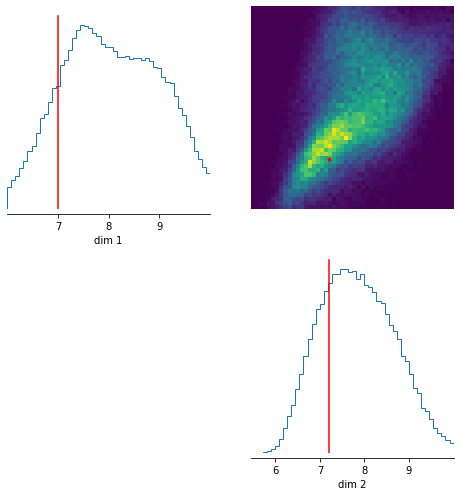

In [9]:
posterior = infer(simulator, prior, method='SNPE', num_simulations=1000, num_workers=5)
observation = simulator([7,7.2])
samples = posterior.sample((100000,), x=observation)

_ = analysis.pairplot(samples,
                      points=np.array([7,7.2]),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

print('UA is ',samples[:,0].mean(),'+-',3*samples[:,0].std())
print('k_0 is ',samples[:,1].mean(),'+-',3*samples[:,1].std())

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.11551083 0.04366586 0.03841474]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.88435178 0.03535444 0.03360414]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.84345148 0.08145291 0.0713702 ]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.5308506  0.02250667 0.0220086 ]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.870047   0.11532438 0.09876792]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.62551586 0.02596581 0.02308157]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.008323   0.00450162 0.00403574]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.21918559 0.04020664 0.0354456 ]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. 

 Neural network successfully converged after 137 epochs.

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

UA is  tensor(791280.1875) +- tensor(277196.1562)
k_0 is  tensor(7.4337e+10) +- tensor(1.6365e+10)


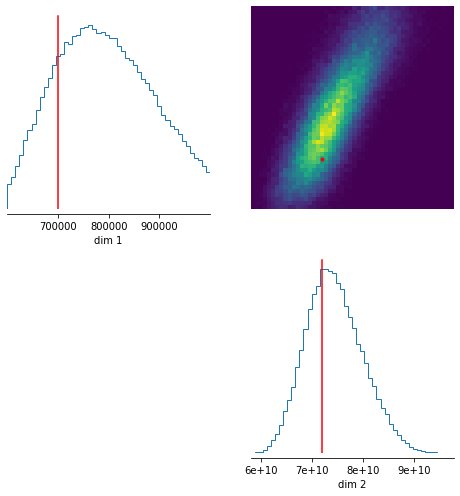

In [30]:
posterior = infer(simulator, prior, method='SNPE', num_simulations=1000, num_workers=5)

observation = simulator(true_params)
samples = posterior.sample((100000,), x=observation)

_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

print('UA is ',samples[:,0].mean(),'+-',3*samples[:,0].std())
print('k_0 is ',samples[:,1].mean(),'+-',3*samples[:,1].std())

In [19]:
store = []
for num_sim in range(10):

    try:
        posterior = infer(simulator, prior, method='SNPE', num_simulations=1000, num_workers=5)

        observation = simulator(true_params)
        samples = posterior.sample((100000,), x=observation)  

        par_1 = [float(sample[0]) for sample in samples]
        par_2 = [float(sample[1]) for sample in samples]
        store.append([par_1,par_2])
    except:
        continue
  

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.65278535 0.11399219 0.09956003]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.87941002 0.12343139 0.10637282]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [3.15780225 0.08818337 0.08061436]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.7439937  0.08690028 0.07617314]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.04391373 0.05508476 0.04539461]


 Neural network successfully converged after 184 epochs.

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

...

/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.31200648 0.05214542 0.04573937]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.25711913 0.13846143 0.11860919]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.53017707 0.05421859 0.04869593]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.90952768 0.03415113 0.03284644]


 Neural network successfully converged after 106 epochs.

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.50011631 0.05662804 0.05016642]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [3.15420906 0.13806355 0.12177204]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.03455763 0.00945593 0.00994451]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.92153039 0.05234903 0.04605853]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.37761081 0.07388075 0.06346957]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [3.04503775 0.07252457 0.06437066]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [3.05565354 0.137555   0.12047505]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.54823419 0.05057777 0.04269952]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. 

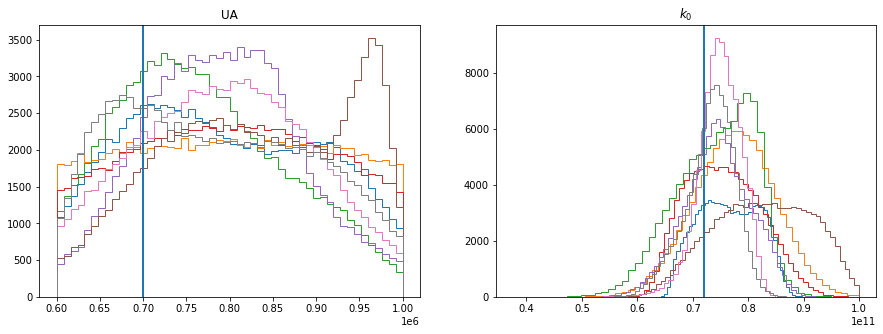

In [20]:
# Plotting the parameters  
plt.subplots(1,2,figsize=(15,5))

UA, k_0 = true_params

plt.subplot(1,2,1)
for item in store:
    plt.title('UA')
    _ = plt.hist(item[0],bins=50,histtype='step')
    plt.axvline(UA)


plt.subplot(1,2,2)
for item in store:
    plt.title('$k_0$')
    _ = plt.hist(item[1],bins=50,histtype='step')
    plt.axvline(k_0)


In [14]:
posterior = infer(simulator, prior, method='SNPE', num_simulations=10000, num_workers=2)

observation = simulator(true_params)
samples = posterior.sample((100000,), x=observation)

_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

print('UA is ',samples[:,0].mean(),'+-',3*samples[:,0].std())
print('k_0 is ',samples[:,1].mean(),'+-',3*samples[:,1].std())

Running 10000 simulations in 10000 batches.:   0%|          | 0/10000 [00:00<?, ?it/s]

/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [3.86686103 0.1258992  0.11245039]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [17.02920608  0.61526275  0.53791149]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.93073635 0.07498414 0.06716267]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.04246744 0.03748702 0.0330168 ]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.27735079 0.01097815 0.01033286]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [1.431369   0.00897113 0.00798905]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.33650838 0.10541853 0.09287708]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converged. [2.70567306 0.08763398 0.07568394]
/tmp/ipykernel_171659/2901613863.py:25: RuntimeWarning: Solution not converge

TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGSEGV(-11)}

In [30]:
model_description = read_model_description("CoupledClutches.fmu")

In [31]:
model_description

ModelDescription(fmiVersion='2.0', modelName='CoupledClutches', coSimulation=CoSimulation(modelIdentifier='CoupledClutches'), modelExchange=None, scheduledExecution=None)

In [8]:
model_description = read_model_description(fmu_filename)

In [9]:
# collect the value references
vrs = {}
for variable in model_description.modelVariables:
    vrs[variable.name] = variable.valueReference

In [10]:
vrs

{'C': 0,
 'T': 1,
 'Tc': 2,
 'der(C)': 3,
 'der(T)': 4,
 'der(Tc)': 5,
 'k': 7,
 'Ci': 8,
 'Qc': 9,
 'Tci': 10,
 'Ti': 11,
 'UA': 12,
 'k_0': 13}

In [34]:
result = simulate_fmu(
    filename='CoupledClutches.fmu',
    start_time=0,
    stop_time=1.5,
    step_size=1e-2,
    output_interval=2e-2,
    start_values={'CoupledClutches1_freqHz': 0.4})

Exception: The FMU cannot be simulated on the current platform (linux64).

In [18]:
variable

ScalarVariable(name='k', type='Real', clocks=[], dimensions=[], dimensionValueReferences=[])

In [15]:
from fmpy import read_model_description, extract
from fmpy.fmi2 import FMU2Slave

unzipdir = extract(fmu_filename)

fmu = FMU2Slave(guid=model_description.guid,
                unzipDirectory=unzipdir,
                modelIdentifier=model_description.coSimulation.modelIdentifier,
                instanceName='instance1')

In [28]:
Ci_ref = vrs['Ci']
Ti_ref = vrs['Ti']
Tci_ref = vrs['Tci']
Qc_ref = vrs['Qc']

fmu.instantiate()
fmu.setupExperiment(startTime=0)
fmu.enterInitializationMode()
fmu.exitInitializationMode()


fmu.setReal([Ci_ref, Ti_ref, Tci_ref, Qc_ref], [0,350,350,40])

In [25]:
fmu.

7